Practical 1
AIM: Introduction to Business Analytics:
a. Collect data from a real-life business scenario and perform exploratory data analysis (EDA) to gain insights into the dataset. Use 'OmlineRetail.csv' dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "OnlineRetail.csv"
data = pd.read_csv(url, encoding = "unicode_escape")

In [3]:
print("Dataset Preview:")
data.head()

Dataset Preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print(data.shape)
print("------------------Data Summary------------------")
print(data.info())
data.describe()

(541909, 8)
------------------Data Summary------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
data[data['UnitPrice']<0]
print("\n---Dataset Summary---")
data.describe(include='all')


---Dataset Summary---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [6]:
print("\n---Dataset Summary---")
data.describe(include='all')


---Dataset Summary---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [7]:
data_cleaned = data.dropna(subset=['CustomerID']).copy()
data_cleaned.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
data_cleaned[data_cleaned['UnitPrice']<0]

data_cleaned['TotalPrice'] = data_cleaned['Quantity'] * data_cleaned['UnitPrice']
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [10]:
data_cleaned['InvoiceDate'].dtype

data_cleaned['InvoiceDate'] = pd.to_datetime(data_cleaned['InvoiceDate'])

data_cleaned['Month'] = data_cleaned['InvoiceDate'].dt.month
data_cleaned['Hour'] = data_cleaned['InvoiceDate'].dt.hour
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8


In [11]:
data_cleaned.groupby('Month').agg(total_sales=('TotalPrice','sum'), avg_sales=('TotalPrice','mean'), transactions=('TotalPrice','count'))

,total_sales,avg_sales,transactions
Month,,,
1,475074.380,21.681014,21912
2,436546.150,21.438204,20363
3,579964.610,20.845540,27822
4,426047.851,18.365715,23198
5,648251.080,22.424626,28908
6,608013.160,21.842691,27836
7,574238.481,20.879881,27502
8,616368.000,22.282120,27662
9,931440.372,22.817118,40822


b. Analyze customer data to identify trends and patterns that can be used for business decision-making.

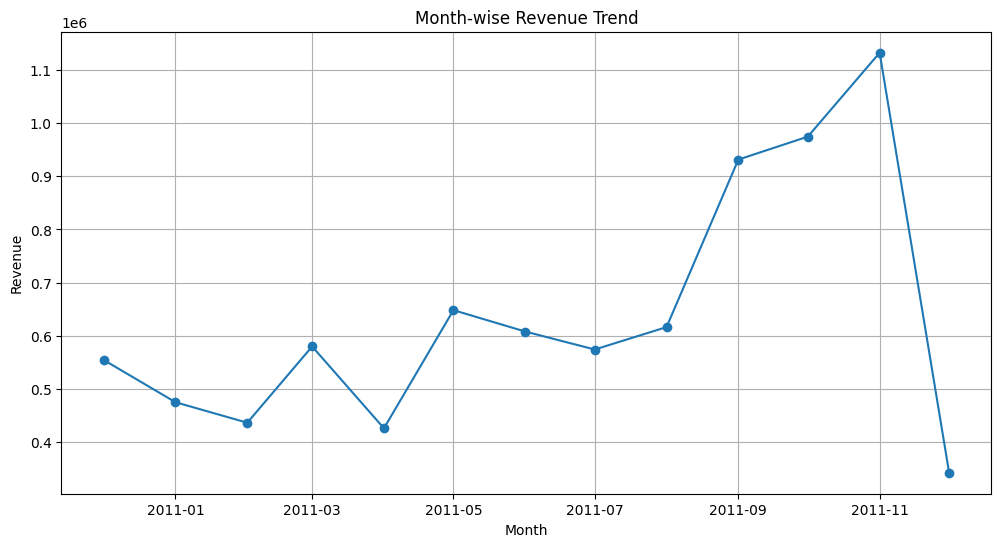

In [12]:
data_cleaned.to_csv('OnlineRetail_Cleaned.csv', index=False)
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("OnlineRetail_Cleaned.csv")

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month and year
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Month-wise revenue
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

# Convert to datetime for plotting
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

# Plot trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'], marker='o')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Month-wise Revenue Trend")
plt.grid(True)
plt.show()

In [13]:
import pandas as pd

# Initial Monthly Summary (Empty)
monthly_summary = pd.DataFrame(columns=['YearMonth', 'TotalPrice'])

def update_monthly_trend(new_data, monthly_summary):
    """
    new_data: New chunk of data (DataFrame)
    monthly_summary: Old aggregated summary (DataFrame)
    """
    # Ensure datetime format
    new_data['InvoiceDate'] = pd.to_datetime(new_data['InvoiceDate'])
    new_data['YearMonth'] = new_data['InvoiceDate'].dt.to_period('M')
    
    # Aggregate new data
    new_summary = new_data.groupby('YearMonth')['TotalPrice'].sum().reset_index()

    # Convert YearMonth to string for merge compatibility
    new_summary['YearMonth'] = new_summary['YearMonth'].astype(str)
    monthly_summary['YearMonth'] = monthly_summary['YearMonth'].astype(str)
    
    # Merge old + new
    updated = (
        pd.concat([monthly_summary, new_summary])
        .groupby('YearMonth')['TotalPrice']
        .sum()
        .reset_index()
        .sort_values('YearMonth')
    )

    return updated

In [14]:
import warnings
warnings.filterwarnings('ignore') # to remove warnings

In [15]:
# Load full dataset
df = pd.read_csv("OnlineRetail_Cleaned.csv")

# Simulating chunks of 5000 rows (like data arriving online)
chunk_size = 5000
monthly_summary = pd.DataFrame(columns=['YearMonth', 'TotalPrice'])

for start in range(0, len(df), chunk_size):
    chunk = df.iloc[start:start+chunk_size]
    monthly_summary = update_monthly_trend(chunk, monthly_summary)

print(monthly_summary)

   YearMonth   TotalPrice
0    2010-12   554604.020
1    2011-01   475074.380
2    2011-02   436546.150
3    2011-03   579964.610
4    2011-04   426047.851
5    2011-05   648251.080
6    2011-06   608013.160
7    2011-07   574238.481
8    2011-08   616368.000
9    2011-09   931440.372
10   2011-10   974603.590
11   2011-11  1132407.740
12   2011-12   342506.380


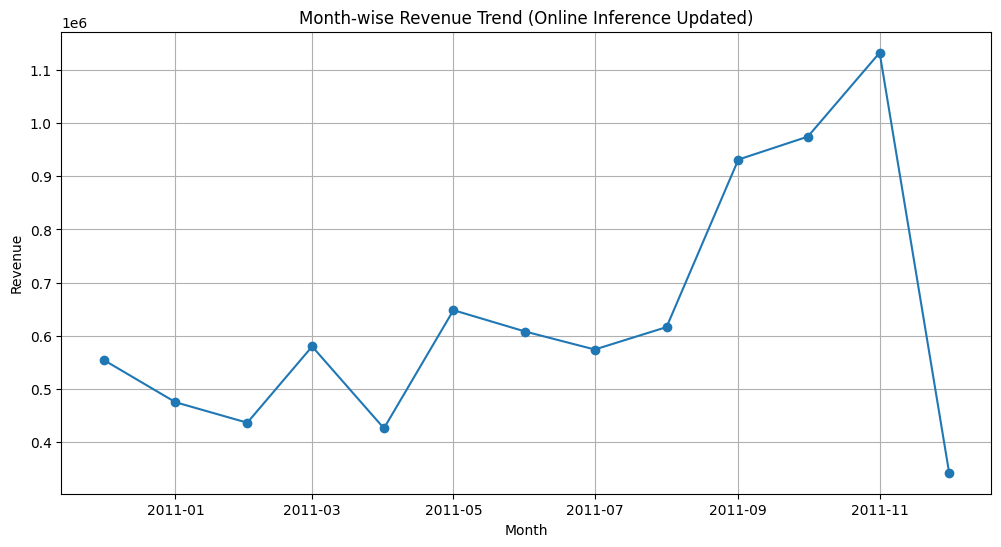

In [16]:
monthly_summary['YearMonth'] = pd.to_datetime(monthly_summary['YearMonth'])

plt.figure(figsize=(12,6))
plt.plot(monthly_summary['YearMonth'], monthly_summary['TotalPrice'], marker='o')
plt.title("Month-wise Revenue Trend (Online Inference Updated)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [17]:
data_cleaned['Country'].value_counts()

Country
United Kingdom          361878
Germany                   9495
France                    8491
EIRE                      7485
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               1877
Portugal                  1480
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     250
Unspecified                244
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


In [18]:
revenue_by_country = data_cleaned.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
revenue_by_country.head()

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Name: TotalPrice, dtype: float64

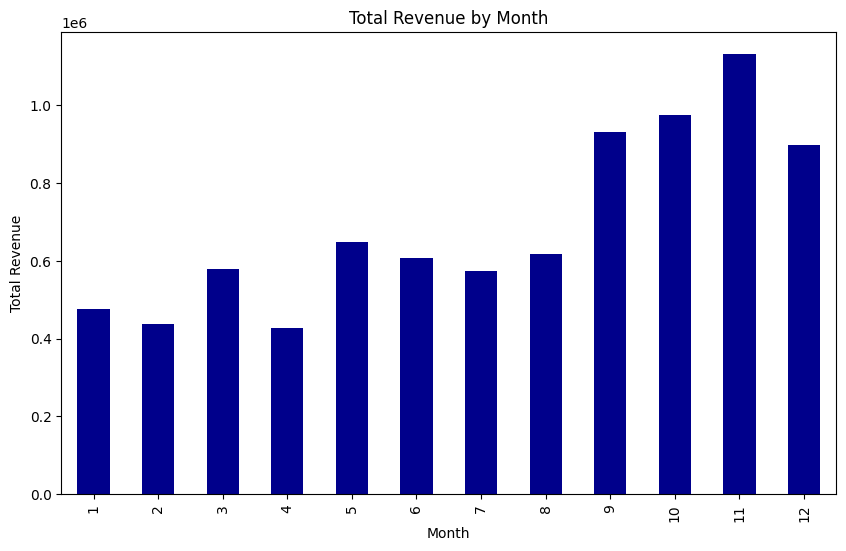

In [19]:
monthly_revenue = data_cleaned.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,6))
monthly_revenue.plot(kind='bar', color='darkblue')
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

In [20]:
top_products = data_cleaned.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("--------Top 10 Products by Revenue--------")
print(top_products)

--------Top 10 Products by Revenue--------
Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalPrice, dtype: float64


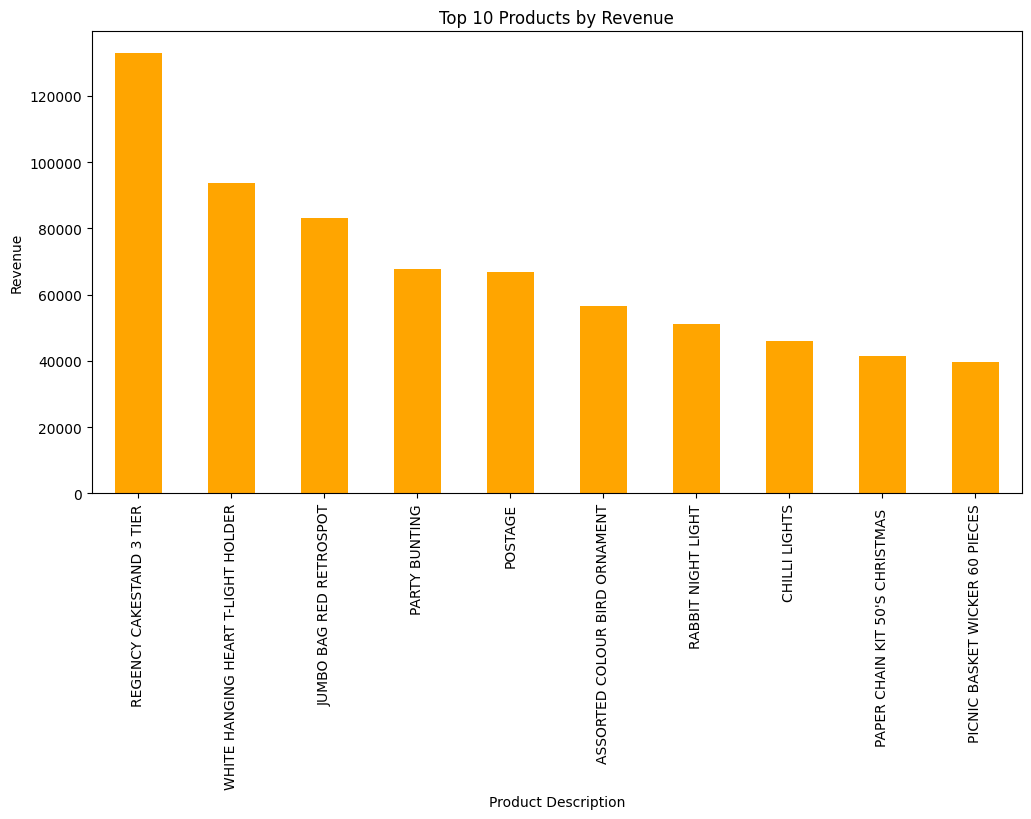

In [21]:
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='orange')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Description")
plt.ylabel("Revenue")
plt.show()

In [22]:
snapshot = data_cleaned['InvoiceDate'].max()
rfm = data_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("--------RFM Table Preview--------")
print(rfm.head())

--------RFM Table Preview--------
            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1        182   4310.00
12348.0          74         31   1797.24
12349.0          18         73   1757.55
12350.0         309         17    334.40


Inference : The business analytics of the Online Retail dataset reveals that a small set of high-value customers and top-selling products drive most of the revenue, highlighting the importance of customer retention and product-focused business strategies.